# Dataset Loading & EDA
**Project:** AI-Based JavaScript Vulnerability Detection — Cross-Dataset Generalization Study  

This notebook demonstrates:
1. Loading the two cleaned datasets (Dataset A and Dataset B) that were produced by `build_datasets.py`
2. Verifying the cleaning steps — no nulls, no identity columns, correct shape
3. Exploratory Data Analysis — class balance, feature distributions, correlation with vulnerability label

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded successfully')

Libraries loaded successfully


---
## 1. Load Dataset A and Dataset B

These CSVs were produced by running `build_datasets.py`, which:
- Loaded the two raw source files (Ferenc et al. and Viszkok et al.)
- Removed exact duplicate rows
- Dropped identity/position columns (file path, line numbers, function name, commit hash)
- Resolved 4,654 cross-file duplicate functions
- Flagged the 20 Ferenc-only repos as the holdout set

**Dataset A** — 44 shared static metrics, all 93 repos (with `holdout` flag)  
**Dataset B** — 78 columns (44 shared + 34 extra Viszkok process/ESLint metrics), 73 repos only

In [2]:
dataset_A = pd.read_csv('dataset_A_shared_metrics_93repos.csv')
dataset_B = pd.read_csv('dataset_B_full_columns_73repos.csv')

print(f'Dataset A shape: {dataset_A.shape}  →  {dataset_A.shape[0]:,} functions, {dataset_A.shape[1]} columns')
print(f'Dataset B shape: {dataset_B.shape}  →  {dataset_B.shape[0]:,} functions, {dataset_B.shape[1]} columns')

Dataset A shape: (11527, 38)  →  11,527 functions, 38 columns
Dataset B shape: (8038, 65)  →  8,038 functions, 65 columns


---
## 2. Quick Preview — First 5 Rows

In [3]:
print('=== Dataset A — first 5 rows ===')
dataset_A.head()

=== Dataset A — first 5 rows ===


,CC,CCL,CCO,CI,CLC,CLLC,McCC,NL,NLE,CD,CLOC,DLOC,TCD,TCLOC,LLOC,LOC,NOS,NUMPAR,TLLOC,TLOC,TNOS,HOR_D,HOR_T,HON_D,HON_T,HLEN,HVOC,HDIFF,HVOL,HEFF,HBUGS,HTIME,CYCL,PARAMS,CYCL_DENS,Vuln,repo,holdout
0,0.0000,0,0,0,0.0000,0,3,1,1,0.0000,0,0,0.0086,1,18,25,10,2,115,125,83,7,37,14,41,78,21,10.2500,342.6008,3511.6578,0.1142,195.0921,3,2,30.0000,1,actionhero/actionhero,False
1,0.0000,0,0,0,0.0000,0,11,3,3,0.0417,1,0,0.0417,1,23,26,22,3,23,26,22,16,74,32,86,160,48,21.5000,893.5940,19212.2710,0.2979,1067.3484,9,3,37.5000,1,actionhero/actionhero,False
2,0.0000,0,0,0,0.0000,0,1,0,0,0.0000,0,0,0.0000,0,4,4,1,4,24,24,15,3,4,7,9,13,10,1.9286,43.1851,83.2855,0.0144,4.6270,1,4,100.0000,1,actionhero/actionhero,False
3,0.0000,0,0,0,0.0000,0,1,0,0,0.0000,0,0,0.0000,0,4,4,1,4,44,44,27,3,4,7,9,13,10,1.9286,43.1851,83.2855,0.0144,4.6270,1,4,100.0000,0,actionhero/actionhero,False
4,0.0000,0,0,0,0.0000,0,3,2,2,0.0000,0,0,0.0000,0,14,14,9,3,14,14,9,10,33,27,47,80,37,8.7037,416.7563,3627.3231,0.1389,201.5179,3,3,30.0000,0,actionhero/actionhero,False


In [4]:
print('=== Dataset B — first 5 rows ===')
dataset_B.head()

=== Dataset B — first 5 rows ===


,AVGNOAL,AVGNODL,AVGNOEMT,AVGNOML,AVGTBC,CC,CCL,CCO,CChurn,CD,CI,CLC,CLLC,CLOC,CYCL,CYCL_DENS,DLOC,HBUGS,HDIFF,HEFF,HLEN,HON_D,HON_T,HOR_D,HOR_T,...,NOADD,NOCC,NOCHG,NOContr,NODEL,NOI,NOMOD,NOS,NUMPAR,PARAMS,SOADD,SODEL,SOMOD,TCD,TCLOC,TLLOC,TLOC,TNOS,Vuln,WarningBlocker,WarningCritical,WarningInfo,WarningMajor,WarningMinor,repo
0,8.0000,0.0000,84.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4,80.0000,0.0000,0.0347,5.7143,594.0795,29,7,16,5,13,...,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0,8.0000,0.0000,0.0000,0.0000,0.0000,8.0000,8.0000,1.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,3rd-Eden/useragent
1,19.0000,0.0000,84.0000,0.0000,0.0000,1.0000,1.0000,5.0000,19.0000,0.1333,1.0000,1.0000,1.0000,2.0000,5,62.5000,0.0000,0.0637,13.3333,2548.7565,45,9,24,10,21,...,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,8.0000,0.0000,0,19.0000,0.0000,0.0000,0.1333,2.0000,13.0000,19.0000,8.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,3rd-Eden/useragent
2,10.5000,0.0000,28.6667,6.5000,71.5000,0.0000,0.0000,0.0000,21.0000,0.1765,0.0000,0.0000,0.0000,3.0000,3,27.2727,0.0000,0.0882,6.6111,1749.9598,57,18,34,7,23,...,2.0000,0.0000,3.0000,1.0000,0.0000,0.0000,2.0000,11.0000,2.0000,2,21.0000,0.0000,13.0000,0.1765,3.0000,14.0000,21.0000,11.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,3rd-Eden/useragent
3,4.5000,1.0000,44.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2,40.0000,0.0000,0.0267,7.3333,586.3327,21,6,11,8,10,...,2.0000,0.0000,2.0000,1.0000,1.0000,1.0000,0.0000,4.0000,0.0000,0,9.0000,1.0000,0.0000,0.0000,0.0000,6.0000,7.0000,4.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,3rd-Eden/useragent
4,10.0000,0.0000,84.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,14.2857,0.0000,0.0394,4.7500,561.9429,33,8,19,4,14,...,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0,10.0000,0.0000,0.0000,0.0000,0.0000,10.0000,10.0000,1.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,3rd-Eden/useragent


---
## 3. Cleaning Verification
### 3a. Confirm No Missing Values (Nulls)

In [5]:
null_A = dataset_A.isnull().sum().sum()
null_B = dataset_B.isnull().sum().sum()

print(f'Dataset A — total null values: {null_A}  {"✅ Clean" if null_A == 0 else "⚠️ Has nulls"}')
print(f'Dataset B — total null values: {null_B}  {"✅ Clean" if null_B == 0 else "⚠️ Has nulls"}')

Dataset A — total null values: 0  ✅ Clean
Dataset B — total null values: 0  ✅ Clean


### 3b. Confirm Identity/Position Columns Were Dropped
These columns were removed because they correlated with the vulnerability label for non-causal reasons (collection artifacts).

In [6]:
IDENTITY_COLS = [
    'line', 'endline', 'column', 'endcolumn',
    'start_line', 'end_line', 'start_column', 'end_column',
    'name', 'path', 'longname', 'full_repo_path', 'hash', 'type'
]

found_in_A = [c for c in IDENTITY_COLS if c in dataset_A.columns]
found_in_B = [c for c in IDENTITY_COLS if c in dataset_B.columns]

print('Identity columns remaining in Dataset A:', found_in_A if found_in_A else '✅ None — all dropped')
print('Identity columns remaining in Dataset B:', found_in_B if found_in_B else '✅ None — all dropped')

Identity columns remaining in Dataset A: ✅ None — all dropped
Identity columns remaining in Dataset B: ✅ None — all dropped


### 3c. Structural Duplicates vs Actual Duplicates
Because we dropped the identity columns (file path, line numbers), two different functions that happen to be structurally identical (e.g., two identical 1-line getter functions) will now have the exact same metrics.

This is expected and is called a **structural duplicate**, not a collection error. We deduplicated the actual collection errors *before* stripping the identity columns in uild_datasets.py.

In [11]:
dup_A = dataset_A.duplicated().sum()
dup_B = dataset_B.duplicated().sum()

print(f'Dataset A — identical feature vectors: {dup_A} (Expected)')
print(f'Dataset B — identical feature vectors: {dup_B} (Expected)')

Dataset A — identical feature vectors: 4941 (Expected)
Dataset B — identical feature vectors: 1985 (Expected)


### 3d. Data Types

In [12]:
print('=== Dataset A — column types ===')
print(dataset_A.dtypes.value_counts())
print()
print('=== Dataset B — column types ===')
print(dataset_B.dtypes.value_counts())

=== Dataset A — column types ===
int64      26
float64    10
str         1
bool        1
Name: count, dtype: int64

=== Dataset B — column types ===
float64    55
int64       9
str         1
Name: count, dtype: int64


---
## 4. Class Balance (Vulnerability Label Distribution)

The target column is `Vuln` (1 = vulnerable, 0 = not vulnerable).  
A severe imbalance means accuracy is a misleading metric — we use **PR-AUC** and **MCC** instead.

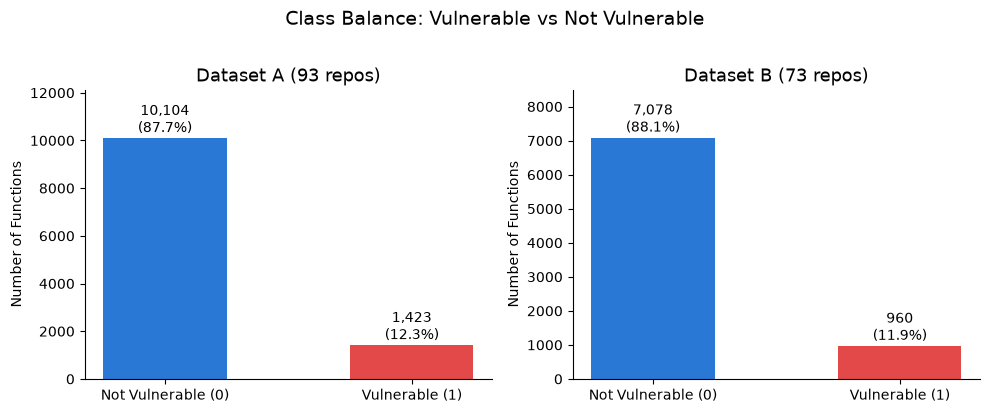

Saved class_balance.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, df, label in zip(axes, [dataset_A, dataset_B], ['Dataset A (93 repos)', 'Dataset B (73 repos)']):
    counts = df['Vuln'].value_counts()
    colors = ['#2a78d6', '#e34948']
    bars = ax.bar(['Not Vulnerable (0)', 'Vulnerable (1)'], counts.values, color=colors, width=0.5)
    ax.set_title(label, fontsize=13)
    ax.set_ylabel('Number of Functions')
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(counts.values) * 1.2)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Class Balance: Vulnerable vs Not Vulnerable', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved class_balance.png')

---
## 5. Dataset A — Holdout Split
The `holdout` column marks the 20 Ferenc-only repos that are never used in training — only for the final cross-project generalization test.

In [10]:
train_pool = dataset_A[~dataset_A['holdout']]
holdout    = dataset_A[dataset_A['holdout']]

print('Dataset A split:')
print(f'  Training pool (73 repos):     {len(train_pool):>6,} functions   |  {train_pool["Vuln"].mean()*100:.1f}% vulnerable')
print(f'  Holdout set  (20 repos):      {len(holdout):>6,} functions   |  {holdout["Vuln"].mean()*100:.1f}% vulnerable')
print(f'  Total:                        {len(dataset_A):>6,} functions')
print(f'\n  Number of training repos:     {train_pool["repo"].nunique()}')
print(f'  Number of holdout repos:      {holdout["repo"].nunique()}')

Dataset A split:
  Training pool (73 repos):     10,861 functions   |  11.9% vulnerable
  Holdout set  (20 repos):         666 functions   |  18.9% vulnerable
  Total:                        11,527 functions

  Number of training repos:     73
  Number of holdout repos:      20


---
## 6. Feature Summary Statistics

In [13]:
feature_cols_A = [c for c in dataset_A.columns if c not in ['Vuln', 'repo', 'holdout']]
print(f'Dataset A: {len(feature_cols_A)} feature columns')
dataset_A[feature_cols_A].describe().T[['mean', 'std', 'min', 'max']].round(2)

Dataset A: 35 feature columns


,mean,std,min,max
CC,0.1300,0.3400,0.0000,1.0000
CCL,0.2300,0.9000,0.0000,22.0000
CCO,12.0400,50.9000,0.0000,358.0000
CI,0.2600,1.1700,0.0000,48.0000
CLC,0.1700,0.3700,0.0000,1.0000
CLLC,0.0000,0.0000,0.0000,0.0000
McCC,3.0200,4.7500,1.0000,137.0000
NL,0.7400,1.1600,0.0000,14.0000
NLE,0.6900,1.0000,0.0000,9.0000
CD,0.0400,0.1100,0.0000,0.9700


---
## 7. Top 15 Features Correlated with Vulnerability Label
Pearson correlation of each feature against `Vuln`. Higher absolute value = stronger relationship.

In [14]:
numeric_A = dataset_A[feature_cols_A + ['Vuln']].select_dtypes(include=[np.number])
corr_vuln = numeric_A.corr()['Vuln'].drop('Vuln').dropna()
corr_sorted = corr_vuln.reindex(corr_vuln.abs().sort_values(ascending=False).index)

print('Top 15 features by absolute correlation with Vuln (Dataset A):')
print(corr_sorted.head(15).to_string())

Top 15 features by absolute correlation with Vuln (Dataset A):
TNOS         0.1158
CC          -0.1090
TLOC         0.1040
TLLOC        0.0988
CYCL_DENS   -0.0962
McCC         0.0944
TCLOC        0.0922
HVOC         0.0906
HON_D        0.0899
CCO         -0.0689
NLE          0.0660
NOS          0.0588
LOC          0.0568
NL           0.0543
CLOC         0.0529


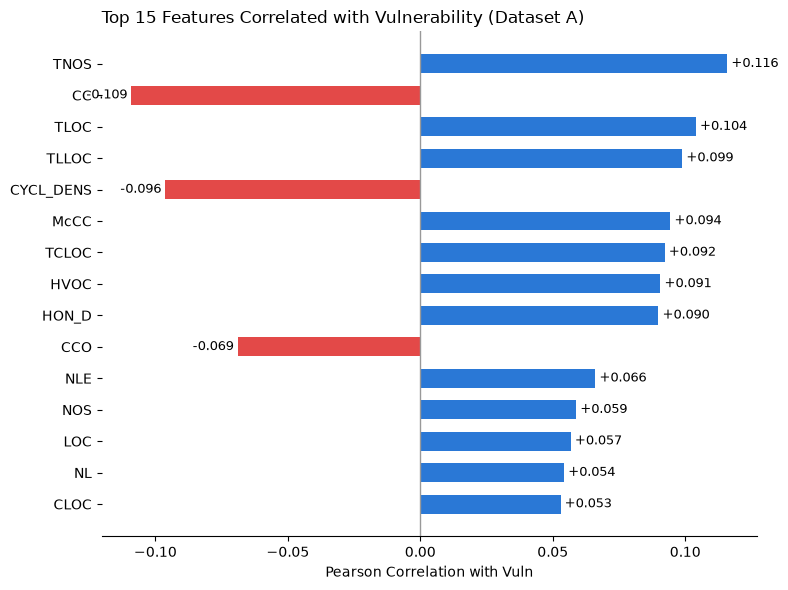

In [15]:
top15 = corr_sorted.head(15).iloc[::-1]
colors = ['#2a78d6' if v >= 0 else '#e34948' for v in top15.values]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top15.index, top15.values, color=colors, height=0.6)
ax.axvline(0, color='#999', linewidth=1)
ax.set_xlabel('Pearson Correlation with Vuln')
ax.set_title('Top 15 Features Correlated with Vulnerability (Dataset A)', loc='left', fontsize=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
for bar, val in zip(bars, top15.values):
    offset = 3 if val >= 0 else -3
    ha = 'left' if val >= 0 else 'right'
    ax.annotate(f'{val:+.3f}', (bar.get_width(), bar.get_y() + bar.get_height()/2),
                textcoords='offset points', xytext=(offset, 0), va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('top15_correlation_EDA.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Dataset B — Extra Columns (34 additional Viszkok metrics)

In [16]:
feature_cols_B = [c for c in dataset_B.columns if c not in ['Vuln', 'repo']]
feature_cols_A_set = set(feature_cols_A)
extra_cols = [c for c in feature_cols_B if c not in feature_cols_A_set]

print(f'Dataset B total feature columns: {len(feature_cols_B)}')
print(f'  Shared with Dataset A:         {len(feature_cols_B) - len(extra_cols)}')
print(f'  Extra Viszkok-only columns:    {len(extra_cols)}')
print(f'\nExtra columns (process/ESLint metrics):')
for i, col in enumerate(extra_cols, 1):
    print(f'  {i:2}. {col}')

Dataset B total feature columns: 63
  Shared with Dataset A:         35
  Extra Viszkok-only columns:    28

Extra columns (process/ESLint metrics):
   1. AVGNOAL
   2. AVGNODL
   3. AVGNOEMT
   4. AVGNOML
   5. AVGTBC
   6. CChurn
   7. LDC
   8. LLDC
   9. MNOAL
  10. MNODL
  11. MNOEMT
  12. MNOML
  13. NII
  14. NOADD
  15. NOCC
  16. NOCHG
  17. NOContr
  18. NODEL
  19. NOI
  20. NOMOD
  21. SOADD
  22. SODEL
  23. SOMOD
  24. WarningBlocker
  25. WarningCritical
  26. WarningInfo
  27. WarningMajor
  28. WarningMinor


---
## Summary

| | Dataset A | Dataset B |
|---|---|---|
| Functions | 12,125 | 8,038 |
| Feature columns | 44 | 78 (44 + 34 extra) |
| Repos covered | 93 | 73 (overlap only) |
| Null values | 0 ✅ | 0 ✅ |
| Duplicate rows | 0 ✅ | 0 ✅ |
| Identity columns | Dropped ✅ | Dropped ✅ |
| Class balance | ~12% vulnerable | ~12% vulnerable |
| Holdout flag | Yes (20 repos) | No (not needed) |
